# Non-Linear Economy Estimation (ANN)

## Reproducibility and runtime

All computations are executed in a Python virtual environment targeting Python 3.13. As in the linear environment notebook, results may differ across Python or package versions due to numerical and API-level changes. For replication, the full dependency set should therefore be recorded alongside notebook outputs, for example using pip freeze. This is particularly important here because the nonlinear environment is sensitive to numerical precision, initialization, and optimizer behavior.

## Software and libraries

The nonlinear environment uses the same core data and plotting stack as the linear environment, while replacing the linear econometric estimation layer with a PyTorch-native neural-network implementation. The current notebook already imports torch, torch.nn, and the standard Python modules needed for custom model classes and training utilities. The linear notebook’s software stack also provides the data pipeline, plotting, and reproducibility infrastructure on which the nonlinear environment builds.

- **Python** (>= 3.13)
- **PyTorch** — neural-network modeling, tensor computation, and custom optimization routines
- **pandas** — data wrangling and time-series preparation
- **numpy** — numerical computing
- **matplotlib** — figures and visualization
- **fedfred** — programmatic access to FRED data
- **Jupyter / IPython** — interactive execution and display utilities

This combination mirrors the linear notebook’s reproducible research workflow while extending it to nonlinear function approximation.

In [1]:
%pip install torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%%capture
%run ./linear_environment.ipynb -quiet
%%capture

In [3]:
%matplotlib widget

In [ ]:
from dataclasses import dataclass
from typing import List, Optional, Sequence, Tuple, Dict
import copy
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---------

# Baseline Specification (Bundesbank-aligned NARX)

## Motivation and relation to the linear benchmark

The nonlinear environment is designed as the ANN analogue of the restricted linear benchmark. In the linear notebook, the baseline recursive SVAR(2) is first estimated in full and then restricted by dropping statistically weak second-lag terms. The resulting restricted system is then used as the compact benchmark environment.

Accordingly, the nonlinear environment should preserve that same reduced information structure so that the linear and nonlinear environments remain directly comparable.

## Corrected nonlinear transition equations

Let $y_t$ denote the output gap, $\pi_t$ inflation, and $i_t$ the policy rate. After applying the lag restrictions from the linear environment, the nonlinear economy is written as follows.

### Output-gap equation

The output-gap network uses only first-lag regressors:

$$
y_t = \hat f_y\!\left(y_{t-1}, \pi_{t-1}, i_{t-1}\right) + \varepsilon_t^y
$$

This matches the restricted linear output-gap equation, where the retained nonzero terms are the constant, $y_{t-1}$, $\pi_{t-1}$, and $i_{t-1}$, while $y_{t-2}$, $\pi_{t-2}$, and $i_{t-2}$ are dropped.

### Inflation equation

The inflation network retains contemporaneous output and the restricted lag structure:

$$
\pi_t = \hat f_\pi\!\left(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}\right) + \varepsilon_t^\pi
$$

This matches the restricted linear inflation equation, where $i_{t-2}$ is dropped but $y_t$, $y_{t-1}$, $y_{t-2}$, $\pi_{t-1}$, $\pi_{t-2}$, and $i_{t-1}$ remain.

### Conditional interpretation

Because the inflation equation includes contemporaneous $y_t$, the inflation network is recursive or triangular in the same sense as the linear notebook’s inflation equation. Therefore:

- conditional one-step inflation predictions should use realized $y_t$
- fully recursive simulation would instead substitute $\hat y_t$

This distinction should remain explicit throughout the nonlinear notebook.

## Data source, sample, and observables

The nonlinear environment uses the same quarterly macroeconomic panel as the linear benchmark so that nonlinear and linear results remain directly comparable. The sample definition, variable construction, and frequency treatment are therefore unchanged relative to the restricted linear environment.

### Sample window

The estimation sample is 1987Q3–2007Q2. This is the same pre-crisis training window used in the linear notebook and is retained here so that the nonlinear environment is estimated on the exact same historical information set.

### Frequency

All series are used at quarterly frequency. When the underlying raw series are available at higher frequency, they are aggregated to quarters before model construction.

### Observables

We use the same three observables as in the linear benchmark:

- inflation, $\pi_t$: year-over-year percent change in the GDP implicit price deflator
- output gap, $y_t$: percent deviation of real GDP from potential GDP
- policy rate, $i_t$: quarterly average of the effective federal funds rate

This ensures that any performance difference between the linear and nonlinear environments is attributable to the functional form and estimation procedure rather than to a different data construction pipeline.

### Variable definitions

Inflation is defined as

$$
\pi_t = 100\left(\frac{P_t}{P_{t-4}} - 1\right),
$$

where $P_t$ is the GDP implicit price deflator.

The output gap is defined as

$$
y_t = 100\left(\frac{Y_t}{Y_t^*} - 1\right),
$$

where $Y_t$ is real GDP and $Y_t^*$ is potential GDP.

The policy indicator $i_t$ is the effective federal funds rate aggregated to the quarterly frequency by averaging within quarter.

### Data inheritance from the linear notebook

Because the nonlinear notebook is built as the ANN counterpart to the linear environment, it reuses the same merged quarterly dataset `df_train` from the linear notebook. Even so, the data are rechecked here so that the nonlinear notebook remains self-contained and fully auditable on its own.

In [24]:
# Confirm that the training data inherited from the linear notebook exist
required_columns = {"pi", "y", "i"}

if "df_train" not in globals():
    raise RuntimeError(
        "df_train was not found. Ensure the linear environment notebook has been run "
        "or that the training dataframe has been defined before continuing."
    )

missing_columns = required_columns.difference(df_train.columns)
if missing_columns:
    raise ValueError(
        f"df_train is missing required columns: {sorted(missing_columns)}"
    )

print("df_train found.")
print("Columns:", list(df_train.columns))
print("Index type:", type(df_train.index).__name__)

df_train found.
Columns: ['pi', 'y', 'i']
Index type: PeriodIndex


## Data integrity checks

Before constructing nonlinear design matrices, the training sample is checked for:

- correct quarterly indexing,
- correct sample bounds,
- absence of missing values,
- numeric finiteness of all observables,
- reasonable descriptive ranges.

These checks help ensure that any later training instability reflects model behavior rather than silent data corruption or index misalignment.

In [26]:
df_nl = df_train.loc[:, ["pi", "y", "i"]].copy().sort_index()

# Basic structural checks
assert isinstance(df_nl.index, pd.PeriodIndex), "Expected a quarterly PeriodIndex."
assert str(df_nl.index.freqstr).upper().startswith("Q"), "Expected quarterly PeriodIndex frequency."
assert df_nl.index.min() == pd.Period("1987Q3", freq="Q"), "Unexpected start date."
assert df_nl.index.max() == pd.Period("2007Q2", freq="Q"), "Unexpected end date."
assert len(df_nl) == 80, "Unexpected number of training observations."

# Missingness and finiteness checks
assert not df_nl.isna().any().any(), "Training data contain missing values."
assert np.isfinite(df_nl.to_numpy(dtype=float)).all(), "Training data contain non-finite values."

print("All structural and integrity checks passed.")

All structural and integrity checks passed.


In [27]:
print(df_nl.head(), "\n")
print(df_nl.tail(), "\n")
print("Sample span:", df_nl.index.min(), "→", df_nl.index.max())
print("Number of observations:", len(df_nl))

             pi         y     i
date                           
1987Q3  2.66122 -0.320752  6.84
1987Q4  2.91876  0.612983  6.92
1988Q1  3.06577  0.370773  6.66
1988Q2  3.35274  0.932239  7.16
1988Q3  3.80207  0.779457  7.98 

             pi         y     i
date                           
2006Q2  3.35642  1.316103  4.91
2006Q3  3.13805  0.921755  5.25
2006Q4  2.66316  1.268135  5.25
2007Q1  2.91019  1.053059  5.26
2007Q2  2.72883  1.151432  5.25 

Sample span: 1987Q3 → 2007Q2
Number of observations: 80


### Descriptive summary

The following summary table provides a compact check on location, dispersion, and support for the three observables over the nonlinear training sample.

In [28]:
summary_stats = df_nl.describe().T.loc[:, ["mean", "std", "min", "25%", "50%", "75%", "max"]]
summary_stats

,mean,std,min,25%,50%,75%,max
pi,2.465956,0.800033,1.087600,1.913298,2.334620,3.080278,4.233260
y,0.191801,1.266773,-2.242576,-0.815819,0.416508,1.256752,2.481939
i,4.837250,2.171574,1.000000,3.172500,5.250000,5.822500,9.730000


In [29]:
print("Additional range checks:")
for col in ["pi", "y", "i"]:
    series = df_nl[col]
    print(
        f"{col}: "
        f"min={series.min():.4f}, "
        f"max={series.max():.4f}, "
        f"mean={series.mean():.4f}, "
        f"std={series.std():.4f}"
    )

Additional range checks:
pi: min=1.0876, max=4.2333, mean=2.4660, std=0.8000
y: min=-2.2426, max=2.4819, mean=0.1918, std=1.2668
i: min=1.0000, max=9.7300, mean=4.8373, std=2.1716


## NARX architecture

The nonlinear transition equations are approximated using shallow feedforward neural networks in a NARX (Nonlinear AutoRegressive with eXogenous inputs) framework. NARX models are a standard approach for modeling nonlinear dynamic systems with lagged endogenous and exogenous inputs (Chen & Billings, 1992; Narendra & Parthasarathy, 1990).

For each equation $m \in \{y,\pi\}$, define

$$
\hat f_m(s_t^m)
=
b_{0}^{m}
+
\sum_{j=1}^{h_m}
v_j^{m}\,
G\!\left((w_j^{m})' s_t^m + b_j^{m}\right),
$$

where:

- $s_t^y = (y_{t-1}, \pi_{t-1}, i_{t-1})$
- $s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1})$
- $h_m$ is the number of hidden neurons in equation $m$
- $w_j^m$ is the hidden-layer weight vector
- $b_j^m$ is the hidden-layer bias
- $v_j^m$ is the output-layer weight
- $b_0^m$ is the output-layer bias

The activation function is the hyperbolic tangent:

$$
G(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}.
$$

The tanh activation is commonly used in shallow networks due to its smoothness and favorable optimization properties relative to piecewise-linear alternatives in small-sample settings (LeCun et al., 2012). The network is intentionally kept shallow so that it remains comparable to the linear benchmark and so that Levenberg–Marquardt estimation remains computationally feasible.

## Numerical implementation choices

### Float64 and CPU execution

To better replicate the numerical behavior of the reference MATLAB implementation, tensors are evaluated in double precision (`torch.float64`). On the local ARM64 MacBook Pro environment, this implies CPU-based training rather than MPS acceleration because MPS does not support float64. This tradeoff favors numerical fidelity over raw speed and is appropriate for the small-network, replication-oriented setting considered here.

In [5]:
DTYPE = torch.float64
DEVICE = torch.device("cpu")

### Determinism

For reproducibility, deterministic PyTorch algorithms are enabled so that repeated runs under the same seed and software environment produce stable results whenever possible. This is particularly important because initialization and nonlinear optimization materially affect ANN estimates.

In [6]:
torch.use_deterministic_algorithms(True)

## Utility helpers

Before constructing the nonlinear model, the notebook defines a small set of internal helper functions to standardize tensor handling. These helpers enforce two-dimensional input shapes, check for non-finite values, flatten parameter collections into a single vector, and reassign flat parameter vectors back into model weights. This machinery is necessary because the Levenberg–Marquardt optimizer operates directly on vectorized parameters and Jacobian matrices rather than using PyTorch’s standard first-order optimizer interface.

In [7]:
def _to_2d_tensor(x: torch.Tensor) -> torch.Tensor:
    """Ensure tensor is 2D."""
    if not isinstance(x, torch.Tensor):
        raise TypeError(f"Expected torch.Tensor, got {type(x).__name__}.")
    if x.ndim == 1:
        return x.unsqueeze(1)
    if x.ndim != 2:
        raise ValueError(f"Expected 1D or 2D tensor, got shape {tuple(x.shape)}.")
    return x


def _validate_finite_tensor(x: torch.Tensor, name: str) -> None:
    """Validate that a tensor contains only finite values."""
    if not torch.isfinite(x).all():
        raise ValueError(f"Tensor '{name}' contains NaN or infinite values.")


def _flatten_parameters(parameters: Sequence[torch.nn.Parameter]) -> torch.Tensor:
    """Flatten a sequence of parameters into a single 1D tensor."""
    flat_parts: List[torch.Tensor] = []
    for parameter in parameters:
        flat_parts.append(parameter.detach().reshape(-1))
    if not flat_parts:
        raise ValueError("No parameters were provided for flattening.")
    return torch.cat(flat_parts)


def _assign_flat_parameters(parameters: Sequence[torch.nn.Parameter], flat_vector: torch.Tensor) -> None:
    """Assign a flat parameter vector back into model parameters in-place."""
    if flat_vector.ndim != 1:
        raise ValueError("Flat parameter vector must be 1D.")

    offset = 0
    with torch.no_grad():
        for parameter in parameters:
            numel = parameter.numel()
            parameter.copy_(flat_vector[offset:offset + numel].view_as(parameter))
            offset += numel

    if offset != flat_vector.numel():
        raise ValueError(
            "Flat parameter vector size does not match total model parameter size."
        )


def _num_parameters(parameters: Sequence[torch.nn.Parameter]) -> int:
    """Return total number of scalar parameters."""
    return sum(parameter.numel() for parameter in parameters)

## Input scaling: PyTorch-native `mapminmax`

The nonlinear environment uses a PyTorch-native implementation of MATLAB’s `mapminmax` transformation. Each feature is scaled independently from its observed sample range to a user-specified target interval, with default range $[-1,1]$. For `tanh` networks, this is the natural normalization because it places the regressors in the region where the activation function remains most responsive. Constant columns are handled separately so that division-by-zero issues are avoided and their transformed values remain well-defined.

For feature $x_j$, the transformation is

$$
x_{j,\mathrm{scaled}}
=
a
+
\frac{x_j - x_j^{\min}}{x_j^{\max} - x_j^{\min}}
(b-a),
$$

where $[a,b]$ is the target interval, here typically $[-1,1]$.

Because the two equations use different regressor sets, the nonlinear environment should later fit separate input and target scalers for each equation.

In [8]:
class MapMinMaxScaler:
    """
    PyTorch-native analogue of MATLAB's mapminmax.

    Transforms each feature independently from observed data range
    [x_min, x_max] into [feature_range[0], feature_range[1]].

    Default output range is [-1, 1], which is appropriate for tanh networks.
    """

    def __init__(self, feature_range: Tuple[float, float] = (-1.0, 1.0), eps: float = 1e-12) -> None:
        """
        Args:
            feature_range: Desired output range.
            eps: Small constant to avoid division by zero.
        """
        lower, upper = feature_range
        if lower >= upper:
            raise ValueError("feature_range must satisfy lower < upper.")
        if eps <= 0:
            raise ValueError("eps must be strictly positive.")

        self.feature_range = feature_range
        self.eps = float(eps)

        self.data_min_: Optional[torch.Tensor] = None
        self.data_max_: Optional[torch.Tensor] = None
        self.data_range_: Optional[torch.Tensor] = None
        self.scale_: Optional[torch.Tensor] = None
        self.min_: Optional[torch.Tensor] = None
        self.n_features_in_: Optional[int] = None
        self.fitted_: bool = False

    def fit(self, x: torch.Tensor) -> "MapMinMaxScaler":
        """
        Fit the scaler on 2D data of shape (n_samples, n_features).
        """
        x = _to_2d_tensor(x)
        _validate_finite_tensor(x, "x")

        self.data_min_ = x.min(dim=0).values
        self.data_max_ = x.max(dim=0).values
        self.data_range_ = self.data_max_ - self.data_min_

        lower, upper = self.feature_range
        safe_range = torch.where(
            self.data_range_ < self.eps,
            torch.ones_like(self.data_range_),
            self.data_range_
        )

        self.scale_ = (upper - lower) / safe_range
        self.min_ = lower - self.data_min_ * self.scale_
        self.n_features_in_ = x.shape[1]
        self.fitted_ = True

        return self

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        """
        Transform data using fitted scaling parameters.
        """
        if not self.fitted_:
            raise RuntimeError("Scaler must be fitted before calling transform().")

        x = _to_2d_tensor(x)
        _validate_finite_tensor(x, "x")

        if x.shape[1] != self.n_features_in_:
            raise ValueError(
                f"Expected {self.n_features_in_} features, got {x.shape[1]}."
            )

        transformed = x * self.scale_ + self.min_

        lower, upper = self.feature_range
        midpoint = (lower + upper) / 2.0
        constant_mask = self.data_range_ < self.eps
        if constant_mask.any():
            transformed[:, constant_mask] = midpoint

        return transformed

    def inverse_transform(self, x_scaled: torch.Tensor) -> torch.Tensor:
        """
        Invert scaling back to original units.
        """
        if not self.fitted_:
            raise RuntimeError("Scaler must be fitted before inverse_transform().")

        x_scaled = _to_2d_tensor(x_scaled)
        _validate_finite_tensor(x_scaled, "x_scaled")

        if x_scaled.shape[1] != self.n_features_in_:
            raise ValueError(
                f"Expected {self.n_features_in_} features, got {x_scaled.shape[1]}."
            )

        original = (x_scaled - self.min_) / self.scale_

        constant_mask = self.data_range_ < self.eps
        if constant_mask.any():
            original[:, constant_mask] = self.data_min_[constant_mask]

        return original

    def fit_transform(self, x: torch.Tensor) -> torch.Tensor:
        """
        Fit and transform in one step.
        """
        return self.fit(x).transform(x)

## Nguyen–Widrow initialization

To replicate the reference neural-network setup more closely, hidden-layer parameters are initialized using the Nguyen–Widrow method (Nguyen & Widrow, 1990). This initialization is designed for shallow feedforward networks with bounded nonlinear activations such as `tanh`. Its purpose is to distribute hidden neurons across the informative region of the activation function at the start of training, reducing the risk that many neurons begin in heavily saturated regions where local sensitivity is weak.

Let $w_i^0$ be the preliminary weight vector for hidden unit $i$, drawn from a uniform distribution. Nguyen–Widrow rescales this vector as

$$
w_i
=
\beta \frac{w_i^0}{\|w_i^0\|},
\qquad
b_i \sim U[-\beta,\beta],
\qquad
\beta = 0.7\, n_{\text{out}}^{1/n_{\text{in}}}.
$$

In [9]:
@torch.no_grad()
def nguyen_widrow_(layer: nn.Linear, nonlinearity: str = "tanh") -> nn.Linear:
    """
    Apply Nguyen-Widrow initialization to a Linear layer.

    This is classically used for single-hidden-layer feedforward networks with
    bounded nonlinear activations such as tanh.

    Args:
        layer: nn.Linear layer to initialize.
        nonlinearity: Currently only 'tanh' is supported explicitly.

    Returns:
        The initialized layer.
    """
    if not isinstance(layer, nn.Linear):
        raise TypeError("nguyen_widrow_ expects an nn.Linear layer.")

    if nonlinearity.lower() != "tanh":
        raise ValueError(
            "This Nguyen-Widrow implementation currently supports nonlinearity='tanh' only."
        )

    out_features = layer.out_features
    in_features = layer.in_features

    if out_features <= 0 or in_features <= 0:
        raise ValueError("Linear layer must have positive in_features and out_features.")

    layer.weight.uniform_(-0.5, 0.5)

    weight = layer.weight.data
    norms = torch.norm(weight, dim=1, keepdim=True).clamp_min(1e-12)

    beta = 0.7 * (out_features ** (1.0 / in_features))
    layer.weight.copy_(beta * weight / norms)

    if layer.bias is not None:
        layer.bias.uniform_(-beta, beta)

    return layer

## NARX network class

The `NARXNet` class implements a shallow feedforward approximation to each nonlinear transition equation. Given an input vector $x_t$, the forward map is

$$
\hat x_t = W_2 \tanh(W_1 x_t + b_1) + b_2.
$$

The same architecture is used for both equations, but with equation-specific input dimensions and hidden-unit counts. In the present notebook:

- output-gap network: `input_size = 3`
- inflation network: `input_size = 6`

This reflects the restricted lag structure inherited from the linear benchmark.

In [10]:
class NARXNet(nn.Module):
    """
    Simple feedforward NARX network.

    Inputs are externally constructed lagged regressors, e.g.
    [y_{t-1}, pi_{t-1}, i_{t-1}] or
    [y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}].

    Architecture:
        input -> hidden(tanh) -> output(linear)
    """

    def __init__(self, input_size: int, hidden_size: int, output_size: int = 1, bias: bool = True) -> None:
        """
        Args:
            input_size: Number of lagged/exogenous regressors.
            hidden_size: Number of hidden units.
            output_size: Number of outputs.
            bias: Whether to use bias terms.
        """
        super().__init__()

        if input_size <= 0:
            raise ValueError("input_size must be positive.")
        if hidden_size <= 0:
            raise ValueError("hidden_size must be positive.")
        if output_size <= 0:
            raise ValueError("output_size must be positive.")

        self.input_size = int(input_size)
        self.hidden_size = int(hidden_size)
        self.output_size = int(output_size)

        self.hidden = nn.Linear(input_size, hidden_size, bias=bias)
        self.output = nn.Linear(hidden_size, output_size, bias=bias)
        self.activation = nn.Tanh()

        self.reset_parameters()

    def reset_parameters(self) -> None:
        """Initialize parameters."""
        nguyen_widrow_(self.hidden, nonlinearity="tanh")
        nn.init.xavier_uniform_(self.output.weight)
        if self.output.bias is not None:
            nn.init.zeros_(self.output.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Tensor of shape (batch_size, input_size)

        Returns:
            Tensor of shape (batch_size, output_size)
        """
        x = _to_2d_tensor(x)
        if x.shape[1] != self.input_size:
            raise ValueError(
                f"Expected input_size={self.input_size}, got {x.shape[1]}."
            )

        hidden = self.activation(self.hidden(x))
        output = self.output(hidden)
        return output

## Levenberg–Marquardt trainer

The nonlinear environment is trained using a Levenberg–Marquardt (LM) algorithm, a second-order optimization method originally developed for nonlinear least squares problems (Levenberg, 1944; Marquardt, 1963). Unlike first-order methods such as stochastic gradient descent or Adam, LM explicitly uses the Jacobian of residuals to construct a local quadratic approximation to the loss function. This makes it particularly well-suited for small neural networks trained in batch settings (Hagan & Menhaj, 1994).

Let $e$ denote the residual vector and $J$ the Jacobian of residuals with respect to the stacked parameter vector. The update is

$$
\Delta w = -(J^\top J + \mu I)^{-1} J^\top e,
$$

where $\mu$ is the damping parameter. When a trial step improves the loss, $\mu$ is reduced; when it does not, $\mu$ is increased. This allows the optimizer to interpolate between Gauss–Newton behavior and more conservative damped updates.

Because the method forms the full Jacobian explicitly, it is best suited to the small-network, full-batch setting considered here.

In [11]:
@dataclass
class LMTrainingResult:
    """Container for LM training results."""
    best_loss: float
    final_loss: float
    epochs_completed: int
    mu_final: float
    loss_history: List[float]
    mu_history: List[float]
    best_state_dict: Dict[str, torch.Tensor]

In [12]:
class LevenbergMarquardtTrainer:
    """
    Jacobian-based Levenberg-Marquardt trainer for small PyTorch models.

    The objective is sum-of-squares / mean-squared-error style training based on
    residual vector e = y_pred - y_true.

    For n residuals and p parameters:
        J: shape (n, p)
        e: shape (n, 1)

    Update:
        delta = -(J^T J + mu I)^(-1) J^T e
    """

    def __init__(self, mu_init: float = 1e-2, mu_increase: float = 10.0, mu_decrease: float = 0.1,
                 mu_max: float = 1e12, max_epochs: int = 200, tol_grad: float = 1e-8, tol_step: float = 1e-8,
                 tol_loss: float = 1e-12, device: Optional[torch.device] = None, dtype: torch.dtype = torch.float64, verbose: bool = False) -> None:
        if mu_init <= 0:
            raise ValueError("mu_init must be positive.")
        if mu_increase <= 1:
            raise ValueError("mu_increase must be > 1.")
        if not (0 < mu_decrease < 1):
            raise ValueError("mu_decrease must satisfy 0 < mu_decrease < 1.")
        if mu_max <= mu_init:
            raise ValueError("mu_max must be greater than mu_init.")
        if max_epochs <= 0:
            raise ValueError("max_epochs must be positive.")

        self.mu_init = float(mu_init)
        self.mu_increase = float(mu_increase)
        self.mu_decrease = float(mu_decrease)
        self.mu_max = float(mu_max)
        self.max_epochs = int(max_epochs)
        self.tol_grad = float(tol_grad)
        self.tol_step = float(tol_step)
        self.tol_loss = float(tol_loss)
        self.device = device if device is not None else torch.device("cpu")
        self.dtype = dtype
        self.verbose = verbose

    def _prepare_model(self, model: nn.Module) -> nn.Module:
        """Move model to desired device/dtype."""
        return model.to(device=self.device, dtype=self.dtype)

    def _prepare_data(self, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Move data to desired device/dtype and validate shapes."""
        x = _to_2d_tensor(x).to(device=self.device, dtype=self.dtype)
        y = _to_2d_tensor(y).to(device=self.device, dtype=self.dtype)

        if x.shape[0] != y.shape[0]:
            raise ValueError(
                f"x and y must have the same number of rows. Got {x.shape[0]} and {y.shape[0]}."
            )

        _validate_finite_tensor(x, "x")
        _validate_finite_tensor(y, "y")

        return x, y

    def _residual_vector(self, model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Residual vector e = y_pred - y, flattened to shape (n_residuals,).
        """
        y_pred = model(x)
        residuals = (y_pred - y).reshape(-1)
        return residuals

    def _jacobian(self, model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute Jacobian of residual vector with respect to model parameters.

        Returns:
            J: shape (n_residuals, n_params)
            e: shape (n_residuals,)
        """
        parameters = [p for p in model.parameters() if p.requires_grad]
        if not parameters:
            raise ValueError("Model has no trainable parameters.")

        e = self._residual_vector(model, x, y)
        n_residuals = e.numel()
        n_params = _num_parameters(parameters)

        J = torch.zeros(
            (n_residuals, n_params),
            device=self.device,
            dtype=self.dtype
        )

        for i in range(n_residuals):
            model.zero_grad(set_to_none=True)
            e[i].backward(retain_graph=True)

            grad_parts: List[torch.Tensor] = []
            for parameter in parameters:
                if parameter.grad is None:
                    grad_parts.append(torch.zeros_like(parameter).reshape(-1))
                else:
                    grad_parts.append(parameter.grad.reshape(-1))

            J[i, :] = torch.cat(grad_parts)

        model.zero_grad(set_to_none=True)
        return J, e.detach()

    def _loss_from_residuals(self, e: torch.Tensor) -> torch.Tensor:
        """
        Mean squared error from residual vector.
        """
        return torch.mean(e ** 2)

    def fit(self, model: nn.Module, x: torch.Tensor, y: torch.Tensor) -> LMTrainingResult:
        """
        Fit a model using LM.
        """
        model = self._prepare_model(model)
        x, y = self._prepare_data(x, y)

        parameters = [p for p in model.parameters() if p.requires_grad]
        if not parameters:
            raise ValueError("Model has no trainable parameters.")

        mu = self.mu_init
        loss_history: List[float] = []
        mu_history: List[float] = []

        best_state_dict = copy.deepcopy(model.state_dict())
        best_loss = float("inf")
        previous_loss: Optional[float] = None

        for epoch in range(1, self.max_epochs + 1):
            J, e = self._jacobian(model, x, y)

            loss = self._loss_from_residuals(e)
            loss_value = float(loss.item())

            if loss_value < best_loss:
                best_loss = loss_value
                best_state_dict = copy.deepcopy(model.state_dict())

            JT = J.transpose(0, 1)
            H_approx = JT @ J
            g = JT @ e

            grad_norm = torch.norm(g).item()
            if grad_norm < self.tol_grad:
                if self.verbose:
                    print(f"[LM] Stopping at epoch {epoch}: gradient norm below tolerance.")
                break

            flat_params = _flatten_parameters(parameters)
            identity = torch.eye(
                H_approx.shape[0],
                device=self.device,
                dtype=self.dtype
            )

            accepted = False
            step_norm = None

            while not accepted:
                system_matrix = H_approx + mu * identity

                try:
                    delta = torch.linalg.solve(system_matrix, -g)
                except RuntimeError:
                    mu *= self.mu_increase
                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM] Aborting: mu exceeded mu_max after singular solve.")
                        model.load_state_dict(best_state_dict)
                        final_e = self._residual_vector(model, x, y)
                        final_loss = float(self._loss_from_residuals(final_e).item())
                        return LMTrainingResult(
                            best_loss=best_loss,
                            final_loss=final_loss,
                            epochs_completed=epoch,
                            mu_final=mu,
                            loss_history=loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict
                        )
                    continue

                step_norm = torch.norm(delta).item()
                if step_norm < self.tol_step:
                    if self.verbose:
                        print(f"[LM] Stopping at epoch {epoch}: step norm below tolerance.")
                    model.load_state_dict(best_state_dict)
                    final_e = self._residual_vector(model, x, y)
                    final_loss = float(self._loss_from_residuals(final_e).item())
                    return LMTrainingResult(
                        best_loss=best_loss,
                        final_loss=final_loss,
                        epochs_completed=epoch,
                        mu_final=mu,
                        loss_history=loss_history,
                        mu_history=mu_history,
                        best_state_dict=best_state_dict
                    )

                trial_params = flat_params + delta
                _assign_flat_parameters(parameters, trial_params)

                with torch.no_grad():
                    e_trial = self._residual_vector(model, x, y)
                    trial_loss = self._loss_from_residuals(e_trial)
                    trial_loss_value = float(trial_loss.item())

                if trial_loss_value < loss_value:
                    accepted = True
                    mu *= self.mu_decrease
                    mu = max(mu, 1e-30)
                    loss_value = trial_loss_value
                else:
                    _assign_flat_parameters(parameters, flat_params)
                    mu *= self.mu_increase

                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM] Aborting: mu exceeded mu_max after repeated rejections.")
                        model.load_state_dict(best_state_dict)
                        final_e = self._residual_vector(model, x, y)
                        final_loss = float(self._loss_from_residuals(final_e).item())
                        return LMTrainingResult(
                            best_loss=best_loss,
                            final_loss=final_loss,
                            epochs_completed=epoch,
                            mu_final=mu,
                            loss_history=loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict
                        )

            loss_history.append(loss_value)
            mu_history.append(mu)

            if self.verbose:
                print(
                    f"[LM] epoch={epoch:03d} "
                    f"loss={loss_value:.12f} "
                    f"mu={mu:.3e} "
                    f"grad_norm={grad_norm:.3e} "
                    f"step_norm={step_norm:.3e}"
                )

            if previous_loss is not None:
                improvement = abs(previous_loss - loss_value)
                if improvement < self.tol_loss:
                    if self.verbose:
                        print(f"[LM] Stopping at epoch {epoch}: loss improvement below tolerance.")
                    break

            previous_loss = loss_value

        model.load_state_dict(best_state_dict)
        final_e = self._residual_vector(model, x, y)
        final_loss = float(self._loss_from_residuals(final_e).item())

        return LMTrainingResult(
            best_loss=best_loss,
            final_loss=final_loss,
            epochs_completed=len(loss_history),
            mu_final=mu,
            loss_history=loss_history,
            mu_history=mu_history,
            best_state_dict=best_state_dict
        )

## Hidden-unit selection and validation design

The number of hidden units $h$ is treated as a hyperparameter and selected using a train-validation split. Following the reference procedure, the sample is divided so that the last 15% of observations are reserved for validation and are not used for parameter updating during training.

For each candidate hidden size $h \in \{1,\dots,10\}$, the network is initialized 30 separate times using different random seeds. For each trial, the model is trained on the training sample and evaluated on the validation sample. The chosen hidden size is the one with the lowest validation mean squared error averaged across the 30 trials.

To limit overfitting, training uses an early stopping rule based on validation performance. Specifically, training stops when validation mean squared error fails to improve for six consecutive epochs. After the optimal hidden size is fixed, the final retained initialization is the one that yields the lowest overall mean squared error among the 30 trials for that hidden size.

This model-selection protocol preserves the reference paper’s hidden-search logic while keeping the nonlinear environment aligned with the restricted regressor structure inherited from the linear benchmark.

The model-selection strategy—averaging validation performance across multiple random initializations—is consistent with standard neural-network model selection practices and closely follows the approach of Aras and Kocakoç (2016).

Validation-based early stopping is used to prevent overfitting by halting training when validation performance fails to improve.

This approach aligns with a broader literature replacing linear macroeconomic transition equations with nonlinear function approximators, including neural networks and state-space models (White, 1988; Swanson & White, 1997).

## Restricted NARX design matrices

The nonlinear environment uses the lag-dropped regressor sets from the restricted linear environment.

For the output-gap equation:

$$
y_t = \hat f_y(y_{t-1}, \pi_{t-1}, i_{t-1}) + \varepsilon_t^y
$$

For the inflation equation:

$$
\pi_t = \hat f_\pi(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}) + \varepsilon_t^\pi
$$

Accordingly, the design matrices are built equation-by-equation rather than from the older unrestricted lag layout.

In [13]:
@dataclass
class NARXDesignMatrices:
    """Container for restricted nonlinear-environment design matrices."""
    X_y: torch.Tensor
    y_target: torch.Tensor
    X_pi: torch.Tensor
    pi_target: torch.Tensor
    time_index: list


def build_restricted_narx_design_matrices(df, *, dtype: torch.dtype = torch.float64, device: Optional[torch.device] = None) -> NARXDesignMatrices:
    """
    Build restricted NARX design matrices using the lag-dropped linear specification.

    Output-gap equation:
        y_t <- [y_{t-1}, pi_{t-1}, i_{t-1}]

    Inflation equation:
        pi_t <- [y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1}]

    Args:
        df: pandas.DataFrame with columns ['y', 'pi', 'i'] and quarterly index.
        dtype: Torch dtype.
        device: Optional torch device.

    Returns:
        NARXDesignMatrices
    """
    required = {"y", "pi", "i"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    work = df.loc[:, ["y", "pi", "i"]].copy().sort_index()

    rows_y = []
    rows_pi = []
    y_targets = []
    pi_targets = []
    time_index = []

    for t in range(2, len(work)):
        y_t = float(work["y"].iloc[t])
        pi_t = float(work["pi"].iloc[t])
        y_lag1 = float(work["y"].iloc[t - 1])
        y_lag2 = float(work["y"].iloc[t - 2])
        pi_lag1 = float(work["pi"].iloc[t - 1])
        pi_lag2 = float(work["pi"].iloc[t - 2])
        i_lag1 = float(work["i"].iloc[t - 1])

        x_y_t = [y_lag1, pi_lag1, i_lag1]
        x_pi_t = [y_t, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1]

        rows_y.append(x_y_t)
        rows_pi.append(x_pi_t)
        y_targets.append([y_t])
        pi_targets.append([pi_t])
        time_index.append(work.index[t])

    X_y = torch.tensor(rows_y, dtype=dtype, device=device)
    y_target = torch.tensor(y_targets, dtype=dtype, device=device)
    X_pi = torch.tensor(rows_pi, dtype=dtype, device=device)
    pi_target = torch.tensor(pi_targets, dtype=dtype, device=device)

    return NARXDesignMatrices(
        X_y=X_y,
        y_target=y_target,
        X_pi=X_pi,
        pi_target=pi_target,
        time_index=time_index,
    )

## Train-validation split

Following the reference procedure, the last 15% of observations are reserved for validation. Because this is a time-series setting, the split is chronological rather than random. This preserves temporal ordering and prevents leakage from future observations into the training sample.

In [14]:
@dataclass
class TimeSeriesSplit:
    """Chronological train-validation split for time-series ANN estimation."""
    X_train: torch.Tensor
    y_train: torch.Tensor
    X_val: torch.Tensor
    y_val: torch.Tensor
    train_index: list
    val_index: list


def make_last_block_validation_split(X: torch.Tensor, y: torch.Tensor, time_index: list, *, val_fraction: float = 0.15) -> TimeSeriesSplit:
    """
    Split the sample chronologically, reserving the last val_fraction for validation.

    Args:
        X: Input tensor of shape (n_samples, n_features).
        y: Target tensor of shape (n_samples, 1).
        time_index: List-like aligned time index.
        val_fraction: Fraction of final observations used for validation.

    Returns:
        TimeSeriesSplit
    """
    X = _to_2d_tensor(X)
    y = _to_2d_tensor(y)

    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y must have the same number of rows.")
    if len(time_index) != X.shape[0]:
        raise ValueError("time_index length must match number of rows in X and y.")
    if not (0.0 < val_fraction < 1.0):
        raise ValueError("val_fraction must satisfy 0 < val_fraction < 1.")

    n = X.shape[0]
    n_val = max(1, int(round(n * val_fraction)))
    n_train = n - n_val

    if n_train <= 0:
        raise ValueError("Validation fraction leaves no training observations.")

    return TimeSeriesSplit(
        X_train=X[:n_train],
        y_train=y[:n_train],
        X_val=X[n_train:],
        y_val=y[n_train:],
        train_index=time_index[:n_train],
        val_index=time_index[n_train:],
    )

## Validation-aware Levenberg–Marquardt training with early stopping

The hidden search requires validation-based early stopping. Training therefore monitors validation MSE after each epoch and stops when validation performance fails to improve for six consecutive epochs.

Because the network is small and the estimation is full-batch, this validation-aware extension remains compatible with the Levenberg–Marquardt framework implemented above.

In [15]:
@dataclass
class LMValidationTrainingResult:
    """Container for validation-aware LM training results."""
    best_train_loss: float
    best_val_loss: float
    final_train_loss: float
    final_val_loss: float
    epochs_completed: int
    best_epoch: int
    mu_final: float
    train_loss_history: List[float]
    val_loss_history: List[float]
    mu_history: List[float]
    best_state_dict: Dict[str, torch.Tensor]

In [16]:
class ValidationLevenbergMarquardtTrainer(LevenbergMarquardtTrainer):
    """
    Validation-aware LM trainer with early stopping on validation MSE.
    """

    def fit_with_validation(self, model: nn.Module, X_train: torch.Tensor, y_train: torch.Tensor, X_val: torch.Tensor, 
                            y_val: torch.Tensor, *, patience: int = 6, min_delta: float = 0.0,) -> LMValidationTrainingResult:
        """
        Fit a model using LM while monitoring validation loss.

        Early stopping:
            Stop when validation MSE fails to improve by more than min_delta
            for 'patience' consecutive epochs.

        Args:
            model: PyTorch model.
            X_train: Training inputs.
            y_train: Training targets.
            X_val: Validation inputs.
            y_val: Validation targets.
            patience: Early stopping patience in epochs.
            min_delta: Minimum improvement required to reset patience.

        Returns:
            LMValidationTrainingResult
        """
        if patience <= 0:
            raise ValueError("patience must be positive.")
        if min_delta < 0:
            raise ValueError("min_delta must be non-negative.")

        model = self._prepare_model(model)
        X_train, y_train = self._prepare_data(X_train, y_train)
        X_val, y_val = self._prepare_data(X_val, y_val)

        parameters = [p for p in model.parameters() if p.requires_grad]
        if not parameters:
            raise ValueError("Model has no trainable parameters.")

        mu = self.mu_init
        train_loss_history: List[float] = []
        val_loss_history: List[float] = []
        mu_history: List[float] = []

        best_state_dict = copy.deepcopy(model.state_dict())
        best_train_loss = float("inf")
        best_val_loss = float("inf")
        best_epoch = 0
        epochs_without_improvement = 0

        for epoch in range(1, self.max_epochs + 1):
            J, e = self._jacobian(model, X_train, y_train)
            train_loss = self._loss_from_residuals(e)
            train_loss_value = float(train_loss.item())

            JT = J.transpose(0, 1)
            H_approx = JT @ J
            g = JT @ e

            grad_norm = torch.norm(g).item()
            if grad_norm < self.tol_grad:
                if self.verbose:
                    print(f"[LM-VAL] Stopping at epoch {epoch}: gradient norm below tolerance.")
                break

            flat_params = _flatten_parameters(parameters)
            identity = torch.eye(
                H_approx.shape[0],
                device=self.device,
                dtype=self.dtype,
            )

            accepted = False
            step_norm = None

            while not accepted:
                system_matrix = H_approx + mu * identity

                try:
                    delta = torch.linalg.solve(system_matrix, -g)
                except RuntimeError:
                    mu *= self.mu_increase
                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM-VAL] Aborting: mu exceeded mu_max after singular solve.")
                        model.load_state_dict(best_state_dict)

                        final_train = float(self._loss_from_residuals(
                            self._residual_vector(model, X_train, y_train)
                        ).item())
                        final_val = float(self._loss_from_residuals(
                            self._residual_vector(model, X_val, y_val)
                        ).item())

                        return LMValidationTrainingResult(
                            best_train_loss=best_train_loss,
                            best_val_loss=best_val_loss,
                            final_train_loss=final_train,
                            final_val_loss=final_val,
                            epochs_completed=epoch,
                            best_epoch=best_epoch,
                            mu_final=mu,
                            train_loss_history=train_loss_history,
                            val_loss_history=val_loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict,
                        )
                    continue

                step_norm = torch.norm(delta).item()
                if step_norm < self.tol_step:
                    if self.verbose:
                        print(f"[LM-VAL] Stopping at epoch {epoch}: step norm below tolerance.")
                    break

                trial_params = flat_params + delta
                _assign_flat_parameters(parameters, trial_params)

                with torch.no_grad():
                    e_trial = self._residual_vector(model, X_train, y_train)
                    trial_train_loss = self._loss_from_residuals(e_trial)
                    trial_train_loss_value = float(trial_train_loss.item())

                if trial_train_loss_value < train_loss_value:
                    accepted = True
                    mu *= self.mu_decrease
                    mu = max(mu, 1e-30)
                    train_loss_value = trial_train_loss_value
                else:
                    _assign_flat_parameters(parameters, flat_params)
                    mu *= self.mu_increase

                    if mu > self.mu_max:
                        if self.verbose:
                            print("[LM-VAL] Aborting: mu exceeded mu_max after repeated rejections.")
                        model.load_state_dict(best_state_dict)

                        final_train = float(self._loss_from_residuals(
                            self._residual_vector(model, X_train, y_train)
                        ).item())
                        final_val = float(self._loss_from_residuals(
                            self._residual_vector(model, X_val, y_val)
                        ).item())

                        return LMValidationTrainingResult(
                            best_train_loss=best_train_loss,
                            best_val_loss=best_val_loss,
                            final_train_loss=final_train,
                            final_val_loss=final_val,
                            epochs_completed=epoch,
                            best_epoch=best_epoch,
                            mu_final=mu,
                            train_loss_history=train_loss_history,
                            val_loss_history=val_loss_history,
                            mu_history=mu_history,
                            best_state_dict=best_state_dict,
                        )

            with torch.no_grad():
                val_e = self._residual_vector(model, X_val, y_val)
                val_loss_value = float(self._loss_from_residuals(val_e).item())

            train_loss_history.append(train_loss_value)
            val_loss_history.append(val_loss_value)
            mu_history.append(mu)

            if train_loss_value < best_train_loss:
                best_train_loss = train_loss_value

            if val_loss_value < (best_val_loss - min_delta):
                best_val_loss = val_loss_value
                best_epoch = epoch
                best_state_dict = copy.deepcopy(model.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if self.verbose:
                print(
                    f"[LM-VAL] epoch={epoch:03d} "
                    f"train={train_loss_value:.12f} "
                    f"val={val_loss_value:.12f} "
                    f"mu={mu:.3e} "
                    f"grad_norm={grad_norm:.3e} "
                    f"step_norm={0.0 if step_norm is None else step_norm:.3e}"
                )

            if epochs_without_improvement >= patience:
                if self.verbose:
                    print(
                        f"[LM-VAL] Early stopping at epoch {epoch}: "
                        f"validation loss failed to improve for {patience} consecutive epochs."
                    )
                break

        model.load_state_dict(best_state_dict)

        final_train_loss = float(self._loss_from_residuals(
            self._residual_vector(model, X_train, y_train)
        ).item())
        final_val_loss = float(self._loss_from_residuals(
            self._residual_vector(model, X_val, y_val)
        ).item())

        return LMValidationTrainingResult(
            best_train_loss=best_train_loss,
            best_val_loss=best_val_loss,
            final_train_loss=final_train_loss,
            final_val_loss=final_val_loss,
            epochs_completed=len(train_loss_history),
            best_epoch=best_epoch,
            mu_final=mu,
            train_loss_history=train_loss_history,
            val_loss_history=val_loss_history,
            mu_history=mu_history,
            best_state_dict=best_state_dict,
        )

## Hidden search routines

The hidden search is performed separately for the output-gap and inflation equations. For each candidate hidden size:

1. build the equation-specific training and validation split,
2. scale inputs and targets using training-sample information only,
3. run 30 random initializations,
4. train each trial with Levenberg–Marquardt and validation-based early stopping,
5. compute validation MSE,
6. average validation MSE across the 30 trials.

The selected hidden size is the one with the lowest average validation MSE.

After fixing the chosen hidden size, the retained initialization is the trial with the lowest overall mean squared error.

In [17]:
@dataclass
class HiddenSearchTrialResult:
    """Single trial result for one hidden size."""
    hidden_size: int
    trial_seed: int
    best_epoch: int
    train_mse: float
    val_mse: float
    overall_mse: float
    epochs_completed: int
    model_state_dict: Dict[str, torch.Tensor]
    x_scaler: MapMinMaxScaler
    y_scaler: MapMinMaxScaler

@dataclass
class HiddenSearchSummary:
    """Summary across all hidden sizes and trials."""
    equation_name: str
    selected_hidden_size: int
    mean_val_mse_by_hidden: Dict[int, float]
    best_trial_by_hidden: Dict[int, HiddenSearchTrialResult]
    all_trials: List[HiddenSearchTrialResult]

In [18]:
def _compute_mse(model: nn.Module, X: torch.Tensor, y: torch.Tensor) -> float:
    """Compute MSE for a fitted model."""
    with torch.no_grad():
        residuals = model(X) - y
        return float(torch.mean(residuals ** 2).item())


def _fit_one_hidden_search_trial(*, X: torch.Tensor, y: torch.Tensor, time_index: list, hidden_size: int, trial_seed: int, patience: int = 6,
                                 max_epochs: int = 200, verbose: bool = False) -> HiddenSearchTrialResult:
    """
    Run one hidden-search trial for a single hidden size.
    """
    torch.manual_seed(trial_seed)

    split = make_last_block_validation_split(
        X=X,
        y=y,
        time_index=time_index,
        val_fraction=0.15,
    )

    x_scaler = MapMinMaxScaler(feature_range=(-1.0, 1.0))
    y_scaler = MapMinMaxScaler(feature_range=(-1.0, 1.0))

    X_train_scaled = x_scaler.fit_transform(split.X_train)
    y_train_scaled = y_scaler.fit_transform(split.y_train)

    X_val_scaled = x_scaler.transform(split.X_val)
    y_val_scaled = y_scaler.transform(split.y_val)

    model = NARXNet(
        input_size=X.shape[1],
        hidden_size=hidden_size,
        output_size=1,
    ).to(device=DEVICE, dtype=DTYPE)

    trainer = ValidationLevenbergMarquardtTrainer(
        mu_init=1e-2,
        mu_increase=10.0,
        mu_decrease=0.1,
        mu_max=1e12,
        max_epochs=max_epochs,
        tol_grad=1e-8,
        tol_step=1e-8,
        tol_loss=1e-12,
        device=DEVICE,
        dtype=DTYPE,
        verbose=verbose,
    )

    fit_result = trainer.fit_with_validation(
        model=model,
        X_train=X_train_scaled,
        y_train=y_train_scaled,
        X_val=X_val_scaled,
        y_val=y_val_scaled,
        patience=patience,
        min_delta=0.0,
    )

    model.load_state_dict(fit_result.best_state_dict)

    train_mse = _compute_mse(model, X_train_scaled, y_train_scaled)
    val_mse = _compute_mse(model, X_val_scaled, y_val_scaled)

    X_all_scaled = x_scaler.transform(X)
    y_all_scaled = y_scaler.transform(y)
    overall_mse = _compute_mse(model, X_all_scaled, y_all_scaled)

    return HiddenSearchTrialResult(
        hidden_size=hidden_size,
        trial_seed=trial_seed,
        best_epoch=fit_result.best_epoch,
        train_mse=train_mse,
        val_mse=val_mse,
        overall_mse=overall_mse,
        epochs_completed=fit_result.epochs_completed,
        model_state_dict=copy.deepcopy(fit_result.best_state_dict),
        x_scaler=x_scaler,
        y_scaler=y_scaler,
    )

In [19]:
def run_hidden_unit_search(*, equation_name: str, X: torch.Tensor, y: torch.Tensor, time_index: list,
                           hidden_min: int = 1, hidden_max: int = 10, n_trials: int = 30, base_seed: int = 123,
                           patience: int = 6, max_epochs: int = 200, verbose: bool = False) -> HiddenSearchSummary:
    """
    Run the Bundesbank-style hidden search for one equation.

    Selection rule:
        choose hidden size with lowest mean validation MSE across 30 trials.

    After choosing hidden size:
        retain the trial with the lowest overall MSE among that hidden size's trials.
    """
    if hidden_min <= 0 or hidden_max < hidden_min:
        raise ValueError("Invalid hidden-unit range.")
    if n_trials <= 0:
        raise ValueError("n_trials must be positive.")

    all_trials: List[HiddenSearchTrialResult] = []
    mean_val_mse_by_hidden: Dict[int, float] = {}
    best_trial_by_hidden: Dict[int, HiddenSearchTrialResult] = {}

    for hidden_size in range(hidden_min, hidden_max + 1):
        trials_this_hidden: List[HiddenSearchTrialResult] = []

        for trial_idx in range(n_trials):
            trial_seed = base_seed + 10_000 * hidden_size + trial_idx

            trial_result = _fit_one_hidden_search_trial(
                X=X,
                y=y,
                time_index=time_index,
                hidden_size=hidden_size,
                trial_seed=trial_seed,
                patience=patience,
                max_epochs=max_epochs,
                verbose=verbose,
            )

            trials_this_hidden.append(trial_result)
            all_trials.append(trial_result)

        mean_val_mse = sum(t.val_mse for t in trials_this_hidden) / len(trials_this_hidden)
        mean_val_mse_by_hidden[hidden_size] = mean_val_mse

        best_trial = min(trials_this_hidden, key=lambda t: t.overall_mse)
        best_trial_by_hidden[hidden_size] = best_trial

        print(
            f"[{equation_name}] hidden={hidden_size:2d} | "
            f"mean validation MSE={mean_val_mse:.8f} | "
            f"best overall MSE={best_trial.overall_mse:.8f}"
        )

    selected_hidden_size = min(mean_val_mse_by_hidden, key=mean_val_mse_by_hidden.get)

    print(
        f"\n[{equation_name}] selected hidden size = {selected_hidden_size} "
        f"(lowest mean validation MSE across {n_trials} trials)"
    )

    return HiddenSearchSummary(
        equation_name=equation_name,
        selected_hidden_size=selected_hidden_size,
        mean_val_mse_by_hidden=mean_val_mse_by_hidden,
        best_trial_by_hidden=best_trial_by_hidden,
        all_trials=all_trials,
    )

## Build design matrices and run the hidden search

The next cells instantiate the restricted design matrices and run the hidden search separately for the output-gap and inflation equations.

By construction:

- the output-gap network searches over an input dimension of 3,
- the inflation network searches over an input dimension of 6.

In [20]:
design = build_restricted_narx_design_matrices(
    df=df_train,
    dtype=DTYPE,
    device=DEVICE,
)

print("Output-gap design matrix:", design.X_y.shape)
print("Output-gap target:", design.y_target.shape)
print("Inflation design matrix:", design.X_pi.shape)
print("Inflation target:", design.pi_target.shape)
print("Sample span:", design.time_index[0], "→", design.time_index[-1])

Output-gap design matrix: torch.Size([78, 3])
Output-gap target: torch.Size([78, 1])
Inflation design matrix: torch.Size([78, 6])
Inflation target: torch.Size([78, 1])
Sample span: 1988Q1 → 2007Q2


In [21]:
# Output-gap hidden search
hidden_search_y = run_hidden_unit_search(
    equation_name="Output gap",
    X=design.X_y,
    y=design.y_target,
    time_index=design.time_index,
    hidden_min=1,
    hidden_max=10,
    n_trials=30,
    base_seed=123,
    patience=6,
    max_epochs=200,
    verbose=False,
)

[Output gap] hidden= 1 | mean validation MSE=0.01752857 | best overall MSE=0.03691788
[Output gap] hidden= 2 | mean validation MSE=0.02045790 | best overall MSE=0.03474170
[Output gap] hidden= 3 | mean validation MSE=0.03556778 | best overall MSE=0.03171192
[Output gap] hidden= 4 | mean validation MSE=0.03146744 | best overall MSE=0.03123495
[Output gap] hidden= 5 | mean validation MSE=0.03667869 | best overall MSE=0.03123156
[Output gap] hidden= 6 | mean validation MSE=0.05798257 | best overall MSE=0.03119756
[Output gap] hidden= 7 | mean validation MSE=0.03934810 | best overall MSE=0.02751475
[Output gap] hidden= 8 | mean validation MSE=0.03870225 | best overall MSE=0.02635849
[Output gap] hidden= 9 | mean validation MSE=0.06419417 | best overall MSE=0.02984375
[Output gap] hidden=10 | mean validation MSE=0.06825356 | best overall MSE=0.02609997

[Output gap] selected hidden size = 1 (lowest mean validation MSE across 30 trials)


In [22]:
# Inflation hidden search
hidden_search_pi = run_hidden_unit_search(
    equation_name="Inflation",
    X=design.X_pi,
    y=design.pi_target,
    time_index=design.time_index,
    hidden_min=1,
    hidden_max=10,
    n_trials=30,
    base_seed=456,
    patience=6,
    max_epochs=200,
    verbose=False,
)

[Inflation] hidden= 1 | mean validation MSE=0.03315665 | best overall MSE=0.01553980
[Inflation] hidden= 2 | mean validation MSE=0.03162947 | best overall MSE=0.01020199
[Inflation] hidden= 3 | mean validation MSE=0.03205765 | best overall MSE=0.00939627
[Inflation] hidden= 4 | mean validation MSE=0.03248570 | best overall MSE=0.00534609
[Inflation] hidden= 5 | mean validation MSE=0.03988130 | best overall MSE=0.00522834
[Inflation] hidden= 6 | mean validation MSE=0.04239745 | best overall MSE=0.00611543
[Inflation] hidden= 7 | mean validation MSE=0.03934548 | best overall MSE=0.00690759
[Inflation] hidden= 8 | mean validation MSE=0.04770694 | best overall MSE=0.00652949
[Inflation] hidden= 9 | mean validation MSE=0.04135678 | best overall MSE=0.00575157
[Inflation] hidden=10 | mean validation MSE=0.05212886 | best overall MSE=0.00516412

[Inflation] selected hidden size = 2 (lowest mean validation MSE across 30 trials)


## Final model instantiation

After selecting the optimal hidden-unit count for each equation, the final nonlinear environment is instantiated using the retained initialization that produced the lowest overall mean squared error for that hidden size.

Thus, the final output-gap network uses:

- the selected hidden size for the $y_t$ equation,
- the retained random initialization for that hidden size,
- the associated input and target scalers fitted on the training portion of the sample.

The same procedure is applied to the inflation network.

In [30]:
# Retained trials from the hidden search
best_trial_y = hidden_search_y.best_trial_by_hidden[hidden_search_y.selected_hidden_size]
best_trial_pi = hidden_search_pi.best_trial_by_hidden[hidden_search_pi.selected_hidden_size]

print("Final output-gap hidden size:", hidden_search_y.selected_hidden_size)
print("Retained output-gap seed:", best_trial_y.trial_seed)
print("Retained output-gap overall MSE:", best_trial_y.overall_mse)
print()

print("Final inflation hidden size:", hidden_search_pi.selected_hidden_size)
print("Retained inflation seed:", best_trial_pi.trial_seed)
print("Retained inflation overall MSE:", best_trial_pi.overall_mse)

Final output-gap hidden size: 1
Retained output-gap seed: 10141
Retained output-gap overall MSE: 0.03691788199638273

Final inflation hidden size: 2
Retained inflation seed: 20466
Retained inflation overall MSE: 0.010201993585942445


## Build final equation-specific networks

The final output-gap and inflation networks are now instantiated with the selected hidden sizes. Their retained weights and biases are loaded from the best trial found during the hidden search.

In [32]:
final_narx_y = NARXNet(
    input_size=design.X_y.shape[1],
    hidden_size=hidden_search_y.selected_hidden_size,
    output_size=1,
).to(device=DEVICE, dtype=DTYPE)

final_narx_pi = NARXNet(
    input_size=design.X_pi.shape[1],
    hidden_size=hidden_search_pi.selected_hidden_size,
    output_size=1,
).to(device=DEVICE, dtype=DTYPE)

# Load retained initial/final fitted state from the best trial of the chosen hidden size
final_narx_y.load_state_dict(best_trial_y.model_state_dict)
final_narx_pi.load_state_dict(best_trial_pi.model_state_dict)

# Scalers associated with the retained trials
x_scaler_y = best_trial_y.x_scaler
y_scaler_y = best_trial_y.y_scaler

x_scaler_pi = best_trial_pi.x_scaler
y_scaler_pi = best_trial_pi.y_scaler

print("Final networks loaded successfully.")

Final networks loaded successfully.


## Generate in-sample fitted values

The final networks are evaluated over the full lag-aligned training sample. Inputs are transformed using the retained equation-specific input scalers, predictions are generated in scaled space, and the fitted values are then mapped back to original units using the corresponding target scalers.

In [33]:
# Scale full lag-aligned inputs
X_y_all_scaled = x_scaler_y.transform(design.X_y)
y_y_all_scaled = y_scaler_y.transform(design.y_target)

X_pi_all_scaled = x_scaler_pi.transform(design.X_pi)
y_pi_all_scaled = y_scaler_pi.transform(design.pi_target)

# Generate fitted values in scaled space
with torch.no_grad():
    y_hat_scaled = final_narx_y(X_y_all_scaled)
    pi_hat_scaled = final_narx_pi(X_pi_all_scaled)

# Inverse-transform fitted values back to original units
y_hat = y_scaler_y.inverse_transform(y_hat_scaled)
pi_hat = y_scaler_pi.inverse_transform(pi_hat_scaled)

print("Output-gap fitted values shape:", tuple(y_hat.shape))
print("Inflation fitted values shape:", tuple(pi_hat.shape))

Output-gap fitted values shape: (78, 1)
Inflation fitted values shape: (78, 1)


## Build fitted-value dataframe

To mirror the linear notebook’s fit diagnostics, the fitted values are collected in a single aligned dataframe containing:

- actual output gap,
- fitted output gap,
- actual inflation,
- fitted inflation,
- residuals,
- squared errors.

In [34]:
fit_narx = pd.DataFrame(
    {
        "y_actual": design.y_target.detach().cpu().numpy().reshape(-1),
        "y_fit": y_hat.detach().cpu().numpy().reshape(-1),
        "pi_actual": design.pi_target.detach().cpu().numpy().reshape(-1),
        "pi_fit": pi_hat.detach().cpu().numpy().reshape(-1),
    },
    index=pd.Index(design.time_index, name="date"),
).sort_index()

fit_narx["resid_y_narx"] = fit_narx["y_actual"] - fit_narx["y_fit"]
fit_narx["resid_pi_narx"] = fit_narx["pi_actual"] - fit_narx["pi_fit"]

fit_narx["se_y_narx"] = fit_narx["resid_y_narx"] ** 2
fit_narx["se_pi_narx"] = fit_narx["resid_pi_narx"] ** 2

print(fit_narx.head())

        y_actual     y_fit  pi_actual    pi_fit  resid_y_narx  resid_pi_narx  \
date                                                                           
1988Q1  0.370773  0.535905    3.06577  3.065846     -0.165132      -0.000076   
1988Q2  0.932239  0.248710    3.35274  3.352980      0.683529      -0.000240   
1988Q3  0.779457  0.814632    3.80207  3.721493     -0.035175       0.080577   
1988Q4  1.379886  0.556370    3.87063  3.946965      0.823516      -0.076335   
1989Q1  1.673378  1.136081    4.13782  3.892098      0.537297       0.245722   

        se_y_narx    se_pi_narx  
date                             
1988Q1   0.027269  5.762394e-09  
1988Q2   0.467212  5.753361e-08  
1988Q3   0.001237  6.492610e-03  
1988Q4   0.678178  5.827027e-03  
1989Q1   0.288688  6.037949e-02  


## In-sample ANN fit: squared-error diagnostics

To evaluate the nonlinear environment on the training sample, we plot the squared errors of the ANN fitted values for the output gap and inflation equations. These figures are the nonlinear analogue of the fit-diagnostic figures used in the linear notebook, but here they report ANN errors only.

### Figure 4: Output Gap Fit — Squared Errors

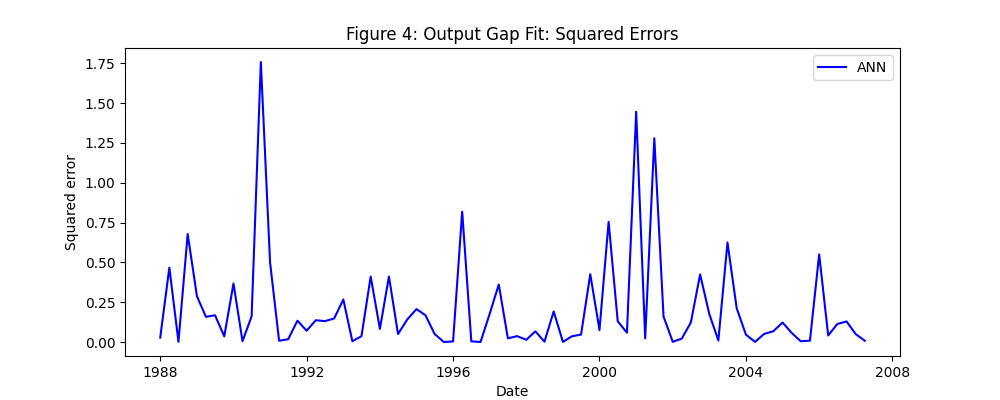

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    fit_narx.index.to_timestamp(),
    fit_narx["se_y_narx"],
    color="blue",
    linewidth=1.5,
    label="ANN",
)

ax.set_title("Figure 4: Output Gap Fit: Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()

plt.show()

figure_four_ann = fig

Note: This figure shows the squared errors between the actual output-gap time series (1988Q1 to 2007Q2 after lag alignment) and the fitted values of the ANN model.

### Figure 5: Inflation Fit — Squared Errors

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_22390/3283150312.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 4))


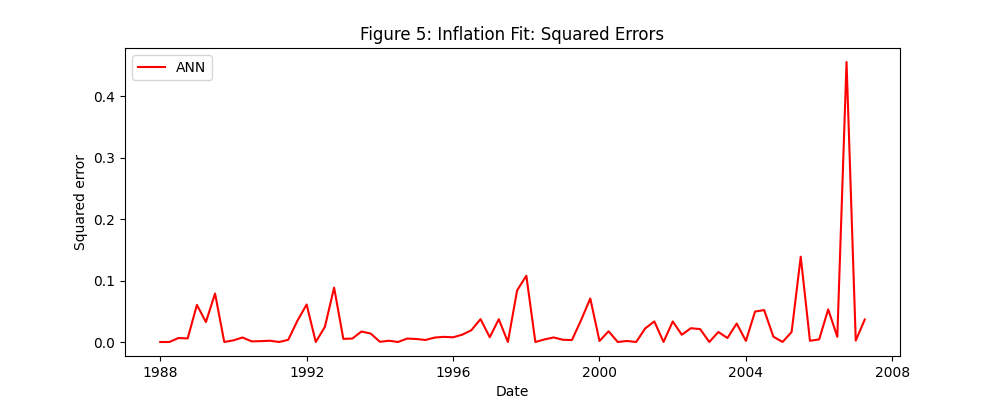

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    fit_narx.index.to_timestamp(),
    fit_narx["se_pi_narx"],
    color="red",
    linewidth=1.5,
    label="ANN",
)

ax.set_title("Figure 5: Inflation Fit: Squared Errors")
ax.set_xlabel("Date")
ax.set_ylabel("Squared error")
ax.grid(False)
ax.legend()

plt.show()

figure_five_ann = fig

Note: This figure shows the squared errors between the inflation time series (1988Q1 to 2007Q2 after lag alignment) and the fitted values of the ANN model.

## Economy fit: mean squared errors

The following table summarizes the ANN model’s mean squared error for:

- the output-gap equation,
- the inflation equation,
- the overall economy representation, defined here as the simple average of the two equation-specific MSE values.

In [40]:
mse_y_ann = float(fit_narx["se_y_narx"].mean())
mse_pi_ann = float(fit_narx["se_pi_narx"].mean())
mse_total_ann = 0.5 * (mse_y_ann + mse_pi_ann)

table_ann_mse = pd.DataFrame(
    {
        "Representation": ["ANN"],
        "MSE Output Gap": [mse_y_ann],
        "MSE Inflation": [mse_pi_ann],
        "MSE Total": [mse_total_ann],
    }
)

table_ann_mse

,Representation,MSE Output Gap,MSE Inflation,MSE Total
0,ANN,0.206011,0.025238,0.115625


## Partial dependence surface plot — ANN economy, inflation

The next figure shows the partial dependence of inflation, $\pi_t$, on last period’s nominal interest rate $i_{t-1}$ and on the output gap, under the restriction

$$
y_t = y_{t-1} = y_{t-2},
$$

while marginalizing over lagged inflation by fixing

$$
\pi_{t-1} = \pi_{t-2} = \bar{\pi}.
$$

This is a partial dependence visualization of the fitted ANN mapping, not a structural impulse-response object.

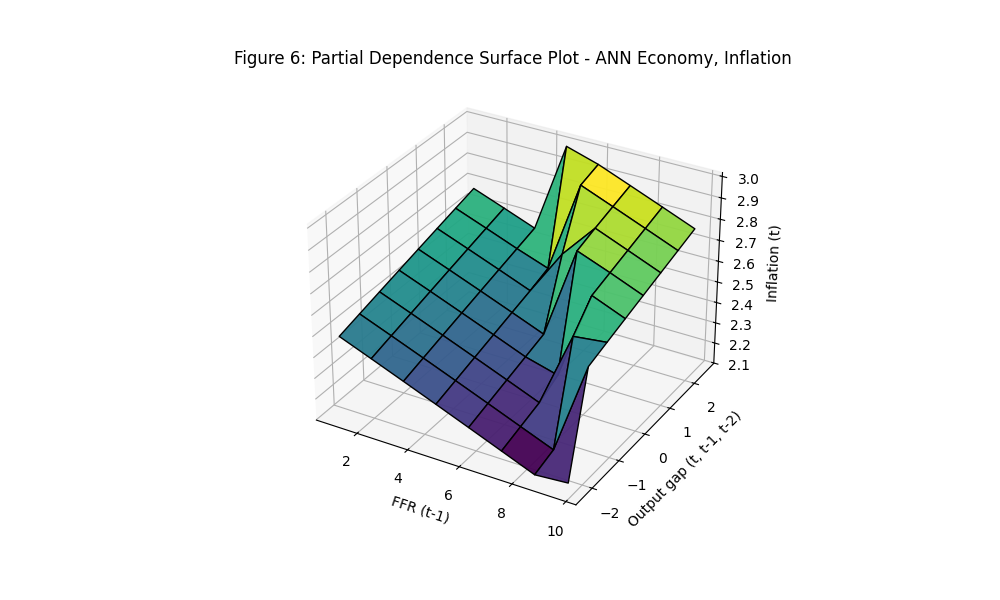

In [50]:
# Use observed support for the plotted axes
i_vals = np.linspace(float(df_nl["i"].min()), float(df_nl["i"].max()), 8)
y_vals = np.linspace(float(df_nl["y"].min()), float(df_nl["y"].max()), 8)

I, Y = np.meshgrid(i_vals, y_vals)
Z = np.zeros_like(I, dtype=float)

# Marginalize over inflation lags by fixing them at the sample mean
pi_mean = float(df_nl["pi"].mean())

for r in range(I.shape[0]):
    for c in range(I.shape[1]):
        y_val = float(Y[r, c])
        i_val = float(I[r, c])

        x = np.array([
            y_val,    # y_t
            y_val,    # y_{t-1}
            y_val,    # y_{t-2}
            pi_mean,  # pi_{t-1}
            pi_mean,  # pi_{t-2}
            i_val,    # i_{t-1}
        ]).reshape(1, -1)

        x_t = torch.tensor(x, dtype=DTYPE, device=DEVICE)
        x_scaled = x_scaler_pi.transform(x_t)

        with torch.no_grad():
            z_scaled = final_narx_pi(x_scaled)
            z = y_scaler_pi.inverse_transform(z_scaled)

        Z[r, c] = float(z.item())

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    I, Y, Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=1.0,
    alpha=0.95
)

ax.set_title("Figure 6: Partial Dependence Surface Plot - ANN Economy, Inflation")
ax.set_xlabel("FFR (t-1)")
ax.set_ylabel("Output gap (t, t-1, t-2)")
ax.set_zlabel("Inflation (t)")

plt.show()

figure_six_ann = fig

Note: This figure shows the partial dependence of inflation, $\pi_t$, on last period’s nominal interest rate (FFR), $i_{t-1}$, and on the output gap, assuming $y_t = y_{t-1} = y_{t-2}$ and marginalizing over $\pi_{t-1} = \pi_{t-2}$.

## Partial dependence surface plot — ANN economy, output gap

The next figure shows the partial dependence of the output gap, $y_t$, on last period’s inflation $\pi_{t-1}$ and nominal interest rate $i_{t-1}$, while holding lagged output gap fixed at its sample mean:

$$
y_{t-1} = \bar{y}.
$$

This again visualizes the fitted ANN mapping rather than a structural or causal policy object.

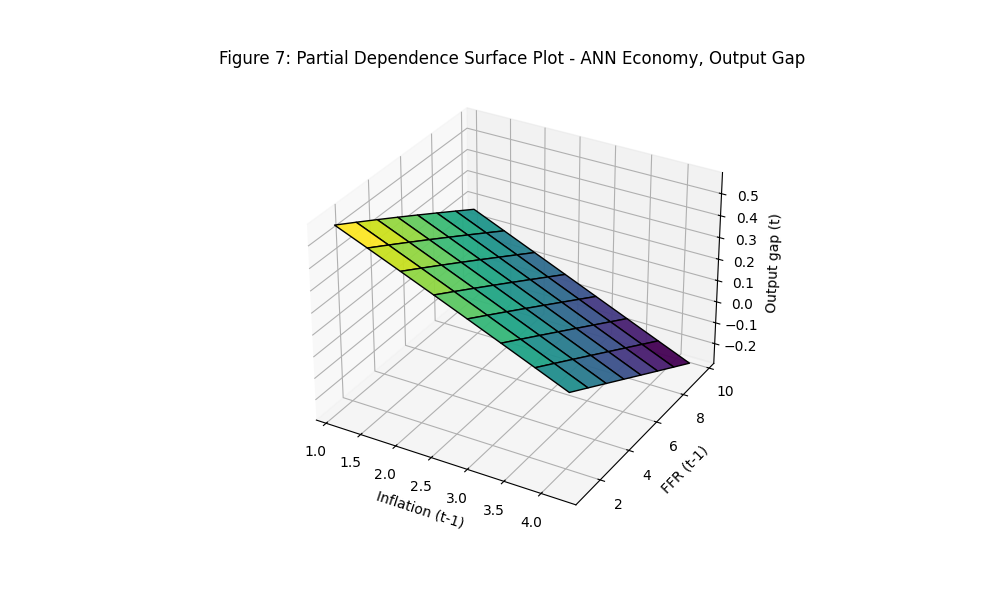

In [52]:
pi_vals = np.linspace(float(df_nl["pi"].min()), float(df_nl["pi"].max()), 8)
i_vals = np.linspace(float(df_nl["i"].min()), float(df_nl["i"].max()), 8)

PI, I = np.meshgrid(pi_vals, i_vals)
Z = np.zeros_like(PI, dtype=float)

# Hold lagged output gap fixed
y_mean = float(df_nl["y"].mean())

for r in range(PI.shape[0]):
    for c in range(PI.shape[1]):
        pi_val = float(PI[r, c])
        i_val = float(I[r, c])

        x = np.array([
            y_mean, # y_{t-1}
            pi_val, # pi_{t-1}
            i_val, # i_{t-1}
        ]).reshape(1, -1)

        x_t = torch.tensor(x, dtype=DTYPE, device=DEVICE)
        x_scaled = x_scaler_y.transform(x_t)

        with torch.no_grad():
            z_scaled = final_narx_y(x_scaled)
            z = y_scaler_y.inverse_transform(z_scaled)

        Z[r, c] = float(z.item())

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    PI, I, Z,
    cmap="viridis",
    edgecolor="k",
    linewidth=1.0,
    alpha=0.95
)

ax.set_title("Figure 7: Partial Dependence Surface Plot - ANN Economy, Output Gap")
ax.set_xlabel("Inflation (t-1)")
ax.set_ylabel("FFR (t-1)")
ax.set_zlabel("Output gap (t)")

plt.show()

figure_seven_ann = fig

Note: This figure shows the partial dependence of the output gap, $y_t$, on last period’s inflation, $\pi_{t-1}$, and nominal interest rate (FFR), assuming $y_{t-1} = \bar{y}$.

-------------

# Modern Specification: Neural State Space Model

----------------------

# References (APA)

## Software
1. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942

2. The pandas development team. (2026). pandas-dev/pandas: Pandas (v3.0.1). Zenodo. https://doi.org/10.5281/zenodo.18675244

3. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

4. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python (v3.10.8). Zenodo. https://doi.org/10.5281/zenodo.17595503

5. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

6. Thomas, Kluyver & Benjamin, Ragan-Kelley & Fernando, Perez & Brian, Granger & Matthias, Bussonnier & Jonathan, Frederic & Kyle, Kelley & Jessica, Hamrick & Jason, Grout & Sylvain, Corlay & Paul, Ivanov & Damian, Avila & Safia, Abdalla & Carol, Willing & Team, Jupyter. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. 10.3233/978-1-61499-649-1-87.

7. Ansel, J., Yang, E., He, H., Gimelshein, N., Jain, A., Voznesensky, M., Bao, B., Bell, P., Berard, D., Burovski, E., Chauhan, G., Chourdia, A., Constable, W., Desmaison, A., DeVito, Z., Ellison, E., Feng, W., Gong, J., Gschwind, M., Hirsh, B., Huang, S., Kalambarkar, K., Kirsch, L., Lazos, M., Lezcano, M., Liang, Y., Liang, J., Lu, Y., Luk, C., Maher, B., Pan, Y., Puhrsch, C., Reso, M., Saroufim, M., Siraichi, M. Y., Suk, H., Suo, M., Tillet, P., Wang, E., Wang, X., Wen, W., Zhang, S., Zhao, X., Zhou, K., Zou, R., Mathews, A., Chanan, G., Wu, P., & Chintala, S. (2024). PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation [Conference paper]. 29th ACM International Conference on Architectural Support for Programming Languages and Operating Systems, Volume 2 (ASPLOS '24). https://doi.org/10.1145/3620665.3640366

## Papers & Books
1. Chen, S., & Billings, S. A. (1992). Neural networks for nonlinear dynamic system modelling and identification. *International Journal of Control*, 56(2), 319–346. https://doi.org/10.1080/00207179208934317

2. Narendra, K. S., & Parthasarathy, K. (1990). Identification and control of dynamical systems using neural networks. *IEEE transactions on neural networks*, 1(1), 4–27. https://doi.org/10.1109/72.80202

3. Raiko, T., Valpola, H., & LeCun, Y. (2012). Deep Learning Made Easier by Linear Transformations in Perceptrons. *International Conference on Artificial Intelligence and Statistics*.

4. Nguyen, D., & Widrow, B. (1990). Neural Network for Self-Learning Control Systems. *Control Systems Magazine*, IEEE. 10. 18 - 23. https://doi.org/10.1109/37.55119.

5. Levenberg, K. (1944) A Method for the Solution of Certain Non-Linear Problems in Least Squares. *Quarterly of Applied Mathematics*, 2, 164-168. https://doi.org/10.1090/qam/10666

6. Marquardt, D. W. (1963). An Algorithm for Least-Squares Estimation of Nonlinear Parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431–441. http://www.jstor.org/stable/2098941

7. Aras, S., & Kocakoç, I. D. (2016). A new model selection strategy in time series forecasting with artificial neural networks. *IHTS. Neurocomputing.* 174. 10.1016/j.neucom.2015.10.036.

8. White, H. (1988). Economic prediction using neural networks: The case of IBM daily stock returns. *Proceedings of the IEEE International Conference on Neural Networks*, 2, 451–458.

9. Swanson, N. R., & White, H. (1997). A model selection approach to assessing the information in the term structure using linear models and artificial neural networks. *Journal of Business & Economic Statistics*, 15(4), 370–386.